In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
#datasetup
data = {
    "Traffic Load": ["High", "High", "Medium", "Medium", "Low", "Low"],
    "Temperature": [40, 35, 27.5, 28, 20, 25],
    "Rainfall": [125, 120, 90, 80, 45, 50],
    "Pavement Life": [8, 7, 13, 12, 17, 15]
}

df = pd.DataFrame(data)
print("DATASET")
print(df)


DATASET
  Traffic Load  Temperature  Rainfall  Pavement Life
0         High         40.0       125              8
1         High         35.0       120              7
2       Medium         27.5        90             13
3       Medium         28.0        80             12
4          Low         20.0        45             17
5          Low         25.0        50             15


In [16]:
import pandas as pd


df = pd.DataFrame(data)
print("DATASET")
print(df)
# Replace LabelEncoder with a manual map
traffic_map = {"Low": 0, "Medium": 1, "High": 2}
df["Traffic Load"] = df["Traffic Load"].map(traffic_map)

DATASET
  Traffic Load  Temperature  Rainfall  Pavement Life
0         High         40.0       125              8
1         High         35.0       120              7
2       Medium         27.5        90             13
3       Medium         28.0        80             12
4          Low         20.0        45             17
5          Low         25.0        50             15


In [17]:
#separating into Input features (X) and Target variable (y)
X = df[['Traffic Load', 'Temperature', 'Rainfall']]
y = df['Pavement Life']

print("Input Features (X):")
print(X.head())

print("\nTarget Variable (y):")
print(y.head())


Input Features (X):
   Traffic Load  Temperature  Rainfall
0             2         40.0       125
1             2         35.0       120
2             1         27.5        90
3             1         28.0        80
4             0         20.0        45

Target Variable (y):
0     8
1     7
2    13
3    12
4    17
Name: Pavement Life, dtype: int64



RIDGE REGRESSION
Coefficients: [-0.30976981 -0.17640884 -0.0677259 ]
Intercept: 23.2264303393461


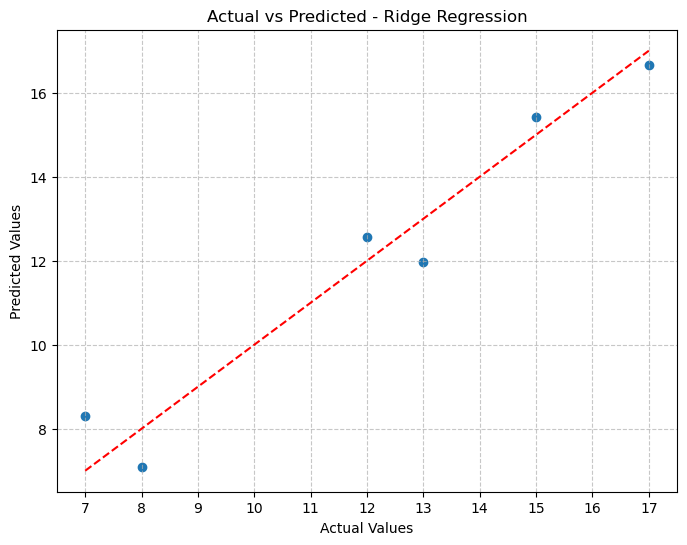

In [18]:
#ridge regression
ridge = Ridge(alpha=1.0)

ridge.fit(X, y)


ridge_pred = ridge.predict(X)

print("\nRIDGE REGRESSION")
print("Coefficients:", ridge.coef_)
print("Intercept:", ridge.intercept_)

plt.figure(figsize=(8,6))
plt.scatter(y, ridge_pred)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(
    np.arange(
        y.min(),
        y.max() + 1,
        1  
    )
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Ridge Regression")
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],                
    'r--'                                                                                
)
plt.show() 


LASSO REGRESSION
Coefficients: [-0.         -0.16194197 -0.07869677]
Intercept: 23.426028077813417


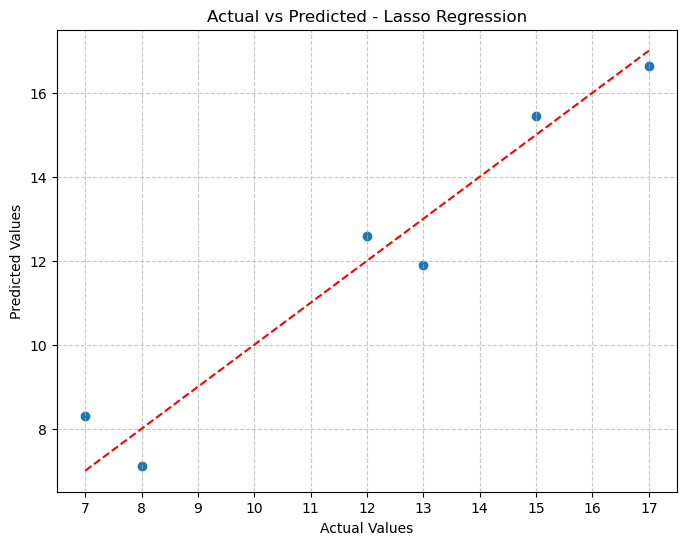

In [19]:
#lasso regression
lasso = Lasso(alpha=0.1)

lasso.fit(X, y)




lasso_pred = lasso.predict(X)

print("\nLASSO REGRESSION")
print("Coefficients:", lasso.coef_)
print("Intercept:", lasso.intercept_)


plt.figure(figsize=(8,6))
plt.scatter(y, lasso_pred)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(
    np.arange(
        y.min(),
        y.max() + 1,
        1
    )
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Lasso Regression")
plt.plot(
    [y.min(),y.max()],
    [y.min(),y.max()],
    'r--'
)
plt.show()

In [20]:
# sample dataset
sample = pd.DataFrame({
    "Traffic Load": [1],
    "Temperature": [32],
    "Rainfall": [130]
})

In [21]:
#prediction
ridge_pred = ridge.predict(sample)
lasso_pred = lasso.predict(sample)

print(f"Predicted Pavement Life (Ridge) for the given data:, {ridge_pred[0]:.2f} years")
print(f"Predicted Pavement Life (Lasso) for the given data:, {lasso_pred[0]:.2f} years")

Predicted Pavement Life (Ridge) for the given data:, 8.47 years
Predicted Pavement Life (Lasso) for the given data:, 8.01 years



RANDOM FOREST REGRESSOR

Feature Importance
        Feature  Importance
0  Traffic Load    0.346712
1   Temperature    0.368112
2      Rainfall    0.285176
Predicted Pavement Life (Random Forest): 10.05


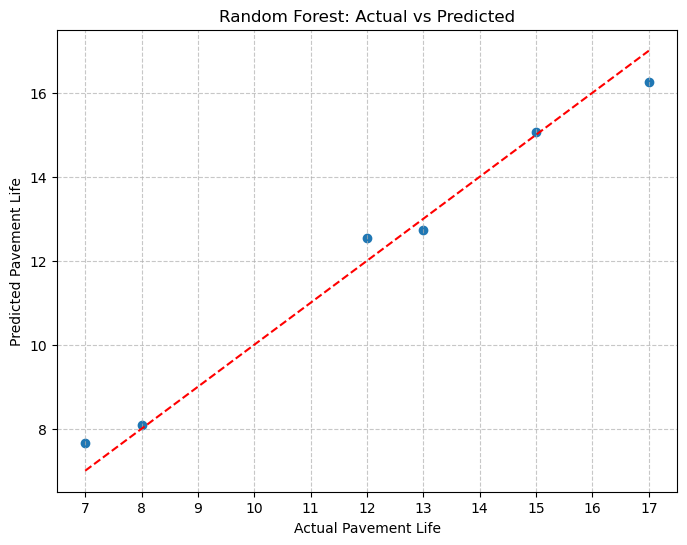

In [12]:
#randam forest regressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

rf_pred = rf.predict(X)

print("\nRANDOM FOREST REGRESSOR")
#feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

print("\nFeature Importance")
print(importance)
#prediction
rf_prediction = rf.predict(sample)

print("Predicted Pavement Life (Random Forest):", rf_prediction[0])
#plot
rf_pred = rf.predict(X)
plt.figure(figsize=(8,6))
plt.scatter(y, rf_pred)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(
    np.arange(
        y.min(),
        y.max() + 1,
        1   
    )
)
plt.xlabel("Actual Pavement Life")
plt.ylabel("Predicted Pavement Life")
plt.title("Random Forest: Actual vs Predicted")

plt.plot(
    [y.min(), y.max()],                      
    [y.min(), y.max()],
    'r--'                                 
)
plt.show() 

In [22]:
print("""
Conclusion:
* The coefficients obtained from Ridge Regression and Lasso Regression were compared.

* In Lasso Regression, the coefficient of Traffic Load became zero, indicating that this feature had less influence on pavement life prediction in this dataset.

* Ridge Regression reduced the coefficient values but retained all features in the model.

* Lasso Regression performed feature selection by setting one coefficient to zero while shrinking the remaining coefficients.

* Based on the Random Forest feature importance values, Temperature was the most influential feature, followed by Rainfall and Traffic Load.

* Therefore, Temperature had the greatest impact on pavement life prediction in this dataset.
""")


Conclusion:
* The coefficients obtained from Ridge Regression and Lasso Regression were compared.

* In Lasso Regression, the coefficient of Traffic Load became zero, indicating that this feature had less influence on pavement life prediction in this dataset.

* Ridge Regression reduced the coefficient values but retained all features in the model.

* Lasso Regression performed feature selection by setting one coefficient to zero while shrinking the remaining coefficients.

* Based on the Random Forest feature importance values, Temperature was the most influential feature, followed by Rainfall and Traffic Load.

* Therefore, Temperature had the greatest impact on pavement life prediction in this dataset.

